# 🔍 AML-мониторинг криптотранзакций
## RegTech | Надзор за цифровыми активами

**Датасет:** Elliptic Bitcoin Dataset (Kaggle)  
**Задача:** Бинарная классификация — легитимная / подозрительная транзакция  
**Цель:** Автоматизация AML-скрининга в соответствии с требованиями FATF Recommendation 16

---
### Структура ноутбука
1. Загрузка данных
2. Проверка качества данных
3. Подготовка признаков
4. EDA — Разведочный анализ
5. Проверка гипотез
6. Подготовка к моделированию (SMOTE)
7. Обучение моделей
8. Оценка и сравнение моделей
9. Оптимизация гиперпараметров
10. Интерпретация (SHAP)
11. Анализ стабильности данных (Data Drift)
12. Сохранение модели

## 1. Загрузка данных
Скачиваем датасет с Kaggle и загружаем два файла: признаки транзакций и метки классов.

In [2]:
import kagglehub
import pandas as pd
import os

#Скачиваем файлы и определяем путь к файлам
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
inner_path = os.path.join(path, 'elliptic_bitcoin_dataset')

#Загружаем главный файл и файл с признаками
features_df = pd.read_csv(os.path.join(inner_path, 'elliptic_txs_features.csv'), header=None)
classes_df  = pd.read_csv(os.path.join(inner_path, 'elliptic_txs_classes.csv'))

print('✅ Данные загружены!')
print(f'Features: {features_df.shape}')
print(f'Classes:  {classes_df.shape}')

100%|██████████| 146M/146M [00:02<00:00, 66.3MB/s]

Extracting files...


✅ Данные загружены!
Features: (203769, 167)
Classes:  (203769, 2)


## 2. Проверка качества данных
Проверяем наличие пропущенных значений — обязательный шаг перед любым анализом.

In [3]:
#Проверка наличия пропущенных значений в каждом столбце
print("Количество пропущенных значений в features_df:", features_df.isnull().sum().sum())
print("Количество пропущенных значений в classes_df:", classes_df.isnull().sum().sum())

Количество пропущенных значений в features_df: 0
Количество пропущенных значений в classes_df: 0


## 3. Подготовка признаков
Переименовываем колонки датасета для удобства работы и объединяем два файла в один.

In [4]:
#Даем названия колонкам основного датасета
n_features = features_df.shape[1] - 2
local_feat_cols = [f'local_feat_{i}' for i in range(1, 94)]
agg_feat_cols   = [f'agg_feat_{i}'   for i in range(1, 73)]
features_df.columns = ['txId', 'timestep'] + local_feat_cols + agg_feat_cols

In [5]:
#Объединяем таблицы по txId
df = features_df.merge(classes_df, on='txId', how='left')
print(df.shape)
df.head()

(203769, 168)


,txId,timestep,local_feat_1,local_feat_2,local_feat_3,local_feat_4,local_feat_5,local_feat_6,local_feat_7,local_feat_8,...,agg_feat_64,agg_feat_65,agg_feat_66,agg_feat_67,agg_feat_68,agg_feat_69,agg_feat_70,agg_feat_71,agg_feat_72,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [6]:
print(df.head(3))      # как выглядят данные
print("\n\nТипы данных в каждой колонке:")
print(df.dtypes)       # типы данных в колонках

        txId  timestep  local_feat_1  local_feat_2  local_feat_3  \
0  230425980         1     -0.171469     -0.184668     -1.201369   
1    5530458         1     -0.171484     -0.184668     -1.201369   
2  232022460         1     -0.172107     -0.184668     -1.201369   

   local_feat_4  local_feat_5  local_feat_6  local_feat_7  local_feat_8  ...  \
0      -0.12197     -0.043875     -0.113002     -0.061584     -0.162097  ...   
1      -0.12197     -0.043875     -0.113002     -0.061584     -0.162112  ...   
2      -0.12197     -0.043875     -0.113002     -0.061584     -0.162749  ...   

   agg_feat_64  agg_feat_65  agg_feat_66  agg_feat_67  agg_feat_68  \
0    -0.600999     1.461330     1.461369     0.018279    -0.087490   
1     0.673103    -0.979074    -0.978556     0.018279    -0.087490   
2     0.439728    -0.979074    -0.978556    -0.098889    -0.106715   

   agg_feat_69  agg_feat_70  agg_feat_71  agg_feat_72    class  
0    -0.131155    -0.097524    -0.120613    -0.119792  unkno

## 4. EDA — Разведочный анализ данных
Изучаем структуру данных, распределение классов, временную динамику и корреляции признаков.

In [7]:
#Смотрим статистическое описание данных в объединенном датасете
print(df.describe())

               txId       timestep  local_feat_1  local_feat_2  local_feat_3  \
count  2.037690e+05  203769.000000  2.037690e+05  2.037690e+05  2.037690e+05   
mean   1.711310e+08      23.843961  2.454849e-17 -7.531922e-18  2.231681e-17   
std    1.104655e+08      15.172170  1.000002e+00  1.000002e+00  1.000002e+00   
min    1.076000e+03       1.000000 -1.729826e-01 -2.105526e-01 -1.756361e+00   
25%    8.433452e+07       9.000000 -1.725317e-01 -1.803266e-01 -1.201369e+00   
50%    1.624375e+08      23.000000 -1.692045e-01 -1.328975e-01  4.636092e-01   
75%    2.454798e+08      38.000000 -1.318553e-01 -5.524241e-02  1.018602e+00   
max    4.032446e+08      49.000000  7.168197e+01  7.359505e+01  2.683580e+00   

       local_feat_4  local_feat_5  local_feat_6  local_feat_7  local_feat_8  \
count  2.037690e+05  2.037690e+05  2.037690e+05  2.037690e+05  2.037690e+05   
mean   6.241732e-17  7.653968e-17  5.858162e-17  3.068561e-17  3.570689e-17   
std    1.000002e+00  1.000002e+00  1.00000

In [8]:
#Проверяем распределение классов
print('Распределение классов:')
print(df['class'].value_counts())
print('  1 - подозрительная операция, 2 - легитимная операция, unknown - неизвестная операция')

Распределение классов:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
  1 - подозрительная операция, 2 - легитимная операция, unknown - неизвестная операция


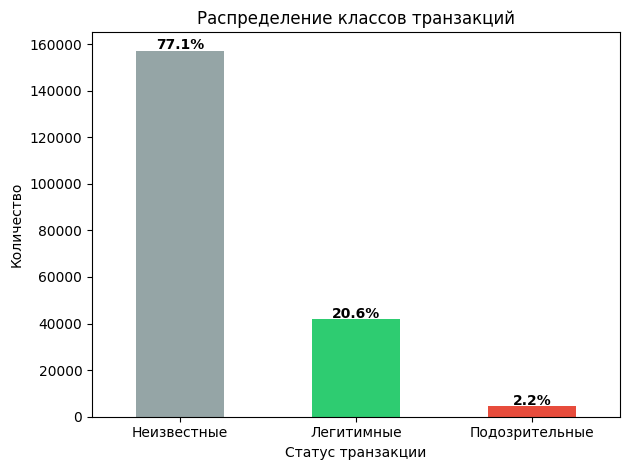

In [9]:
#Визуализируем распределение классов с процентом доли от общего объема транзакций над каждым столбцом

import matplotlib.pyplot as plt

label_map = {'1': 'Подозрительные', '2': 'Легитимные', 'unknown': 'Неизвестные'}
counts = classes_df['class'].map(label_map).value_counts()

ax = counts.plot(kind='bar', color=['#95a5a6', '#2ecc71', '#e74c3c'])
plt.title('Распределение классов транзакций')
plt.xlabel('Статус транзакции')
plt.ylabel('Количество')
plt.xticks(rotation=0)

#Добавляем процент над каждым столбцом
total = counts.sum()
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{v/total*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Временная динамика транзакций
Анализируем как меняется количество и доля мошеннических транзакций по 49 временным шагам.

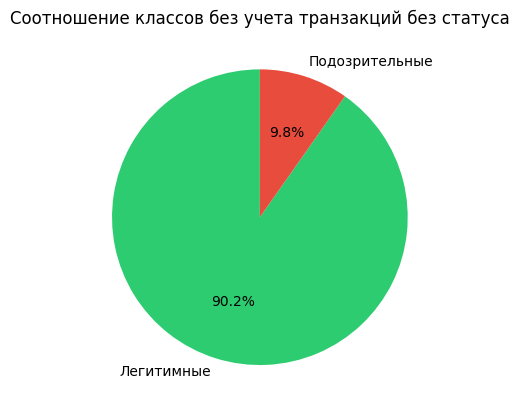

In [10]:
#Визуализируем распределение классов без учета "неизвестных"

labeled = classes_df[classes_df['class'] != 'unknown']['class'].value_counts()
plt.pie(labeled, labels=['Легитимные', 'Подозрительные'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%', startangle=90)
plt.title('Соотношение классов без учета транзакций без статуса')
plt.show()

### 4.4 Анализ корреляций
Определяем какие признаки наиболее связаны с целевой переменной (мошенничество).

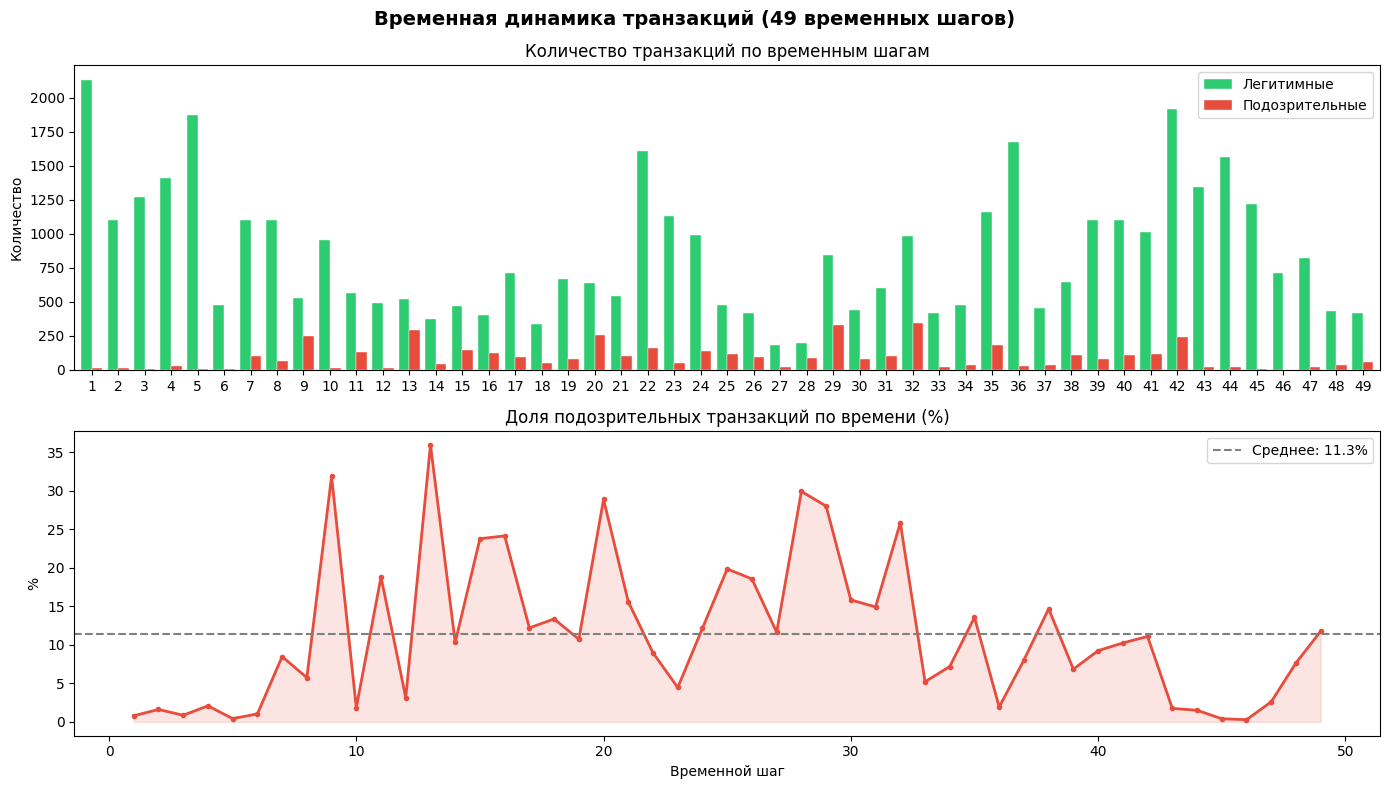

In [29]:
# Временная динамика транзакций
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Временная динамика транзакций (49 временных шагов)', fontsize=14, fontweight='bold')

time_counts = df_labeled.groupby(['timestep', 'label']).size().unstack(fill_value=0)
time_counts.columns = ['Легитимные', 'Подозрительные']

# График 1 — абсолютные значения
time_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                 width=0.8, edgecolor='white', linewidth=0.3)
axes[0].set_title('Количество транзакций по временным шагам')
axes[0].set_xlabel('')
axes[0].set_ylabel('Количество')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# График 2 — доля подозрительных
illicit_rate = time_counts['Подозрительные'] / (time_counts['Легитимные'] + time_counts['Подозрительные'])
axes[1].plot(illicit_rate.index, illicit_rate.values * 100, color='#e74c3c', linewidth=2, marker='o', markersize=3)
axes[1].fill_between(illicit_rate.index, illicit_rate.values * 100, alpha=0.15, color='#e74c3c')
axes[1].set_title('Доля подозрительных транзакций по времени (%)')
axes[1].set_xlabel('Временной шаг')
axes[1].set_ylabel('%')
axes[1].axhline(illicit_rate.mean() * 100, color='gray', linestyle='--',
                label=f'Среднее: {illicit_rate.mean()*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

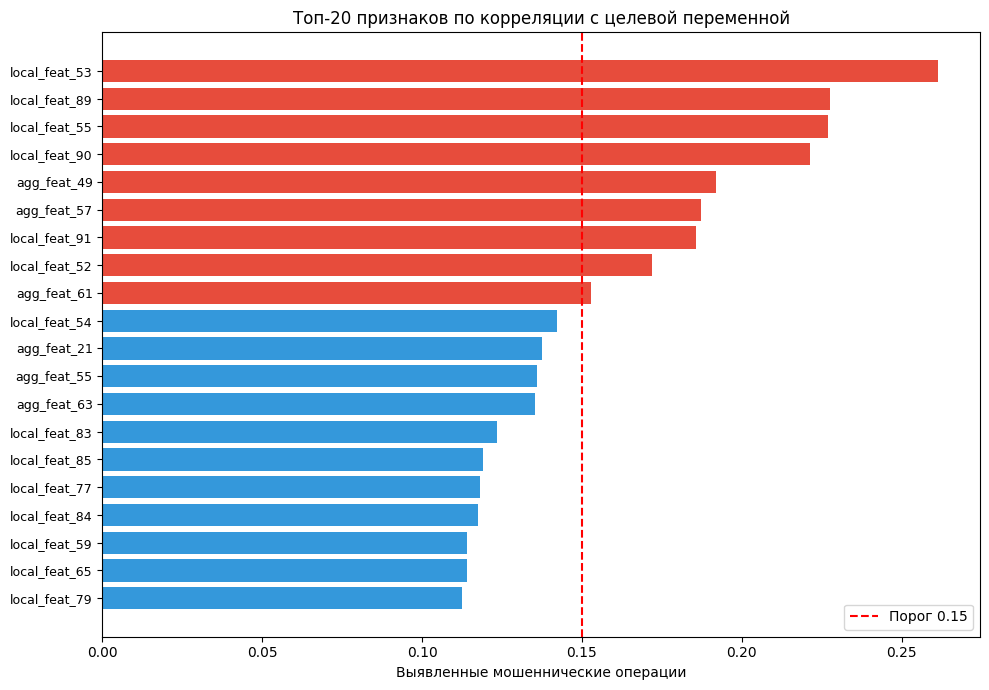

Топ-5 признаков:
local_feat_53    0.261472
local_feat_89    0.227629
local_feat_55    0.227146
local_feat_90    0.221294
agg_feat_49      0.191936
Name: label, dtype: float64


In [11]:
#Анализ корелляций

#Подготовка данных
df_labeled = df[df['class'] != 'unknown'].copy()
df_labeled['label'] = df_labeled['class'].map({'1': 1, '2': 0})

#Корреляции
feat_cols = local_feat_cols + agg_feat_cols
correlations = df_labeled[feat_cols + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)
top20 = correlations.head(20)

#Постоение графика по топ-20
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0.15 else '#3498db' for v in top20.values]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0.15, color='red', linestyle='--', label='Порог 0.15')
ax.set_xlabel('Выявленные мошеннические операции')
ax.set_title('Топ-20 признаков по корреляции с целевой переменной')
ax.legend()
plt.tight_layout()
plt.show()

print('Топ-5 признаков:')
print(top20.head())

## 5. Проверка гипотез
Статистическая проверка гипотез о характеристиках мошеннических транзакций.

# **Проверка следующих гипотез:**


1. Мошеннические транзакции имеют аномальные значения внутренних параметров (суммы, комиссии, структура входов/выходов) по сравнению с легитимными — ***подтверждена*** (t-тест, p < 0.0001)
2. Доля мошеннических транзакций увеличивается со временем — ***отвергнута*** (тест Спирмена, r=-0.009, p=0.95)
3. Распределения признаков мошеннических и легитимных транзакций статистически различаются — ***подтверждена*** (KS-тест, KS=0.617, p < 0.0001)

In [12]:
#Гипотеза 1: Мошеннические транзакции имеют аномальные значения признаков. Проверяем t-тестом — есть ли статистически значимая разница между классами:
from scipy import stats

feat_cols = local_feat_cols + agg_feat_cols

print("Признак | t-статистика | p-value | Вывод")
print("-" * 55)
for feat in top20.head(5).index:
    licit   = df_labeled[df_labeled['label'] == 0][feat]
    illicit = df_labeled[df_labeled['label'] == 1][feat]
    t_stat, p_val = stats.ttest_ind(licit, illicit)
    vyvod = "✅ Различие значимо" if p_val < 0.05 else "❌ Различия нет"
    print(f"{feat} | {t_stat:.2f} | {p_val:.4f} | {vyvod}")

Признак | t-статистика | p-value | Вывод
-------------------------------------------------------
local_feat_53 | 58.45 | 0.0000 | ✅ Различие значимо
local_feat_89 | 50.44 | 0.0000 | ✅ Различие значимо
local_feat_55 | 50.33 | 0.0000 | ✅ Различие значимо
local_feat_90 | 48.97 | 0.0000 | ✅ Различие значимо
agg_feat_49 | -42.20 | 0.0000 | ✅ Различие значимо


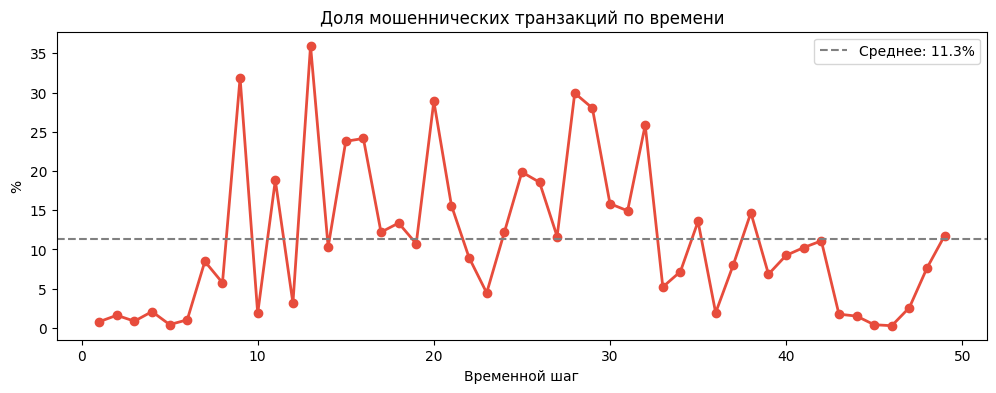

Корреляция Спирмена: -0.009, p-value: 0.9501
❌ Тренда нет


In [13]:
#Гипотеза 2: Доля мошенничества менялась во времени.

#Доля illicit по каждому временному шагу
time_rate = df_labeled.groupby('timestep')['label'].mean() * 100

plt.figure(figsize=(12, 4))
plt.plot(time_rate.index, time_rate.values, marker='o', color='#e74c3c', linewidth=2)
plt.axhline(time_rate.mean(), color='gray', linestyle='--', label=f'Среднее: {time_rate.mean():.1f}%')
plt.title('Доля мошеннических транзакций по времени')
plt.xlabel('Временной шаг')
plt.ylabel('%')
plt.legend()
plt.show()

# Статистическая проверка — есть ли тренд?
from scipy.stats import spearmanr
corr, p_val = spearmanr(time_rate.index, time_rate.values)
print(f'Корреляция Спирмена: {corr:.3f}, p-value: {p_val:.4f}')
print('✅ Тренд существует' if p_val < 0.05 else '❌ Тренда нет')

In [14]:
#Гипотеза 3: Мошеннические транзакции отличаются по распределению от легитимных.Проверяем тестом Колмогорова-Смирнова:
from scipy.stats import ks_2samp

print("Признак | KS-статистика | p-value | Вывод")
print("-" * 55)
for feat in top20.head(5).index:
    licit   = df_labeled[df_labeled['label'] == 0][feat]
    illicit = df_labeled[df_labeled['label'] == 1][feat]
    ks_stat, p_val = ks_2samp(licit, illicit)
    vyvod = "✅ Распределения различаются" if p_val < 0.05 else "❌ Различий нет"
    print(f"{feat} | {ks_stat:.3f} | {p_val:.4f} | {vyvod}")

Признак | KS-статистика | p-value | Вывод
-------------------------------------------------------
local_feat_53 | 0.617 | 0.0000 | ✅ Распределения различаются
local_feat_89 | 0.418 | 0.0000 | ✅ Распределения различаются
local_feat_55 | 0.614 | 0.0000 | ✅ Распределения различаются
local_feat_90 | 0.593 | 0.0000 | ✅ Распределения различаются
agg_feat_49 | 0.428 | 0.0000 | ✅ Распределения различаются


## 6. Подготовка к моделированию
Применяем SMOTE для устранения дисбаланса классов и разбиваем данные на train/test.

Вот дополненный вывод с добавленным разделом об ожидаемых метриках:

---

**Цель и данные**

В рамках данного проекта разрабатывается модель с RegTech-ценностью для автоматизации AML-мониторинга цифровых активов. Для этого был выбран датасет Elliptic Bitcoin Dataset из Kaggle (203,769 транзакций) с использованием файлов признаков транзакций (166 признаков) и статусов легитимности.

**Результаты EDA**

EDA выявил существенный дисбаланс классов: лишь 2.2% транзакций размечены как мошеннические, 20.6% — как легитимные, остальные 77.2% не имеют метки. Пропущенные значения в датасете отсутствуют. Анализ корреляций показал, что локальные признаки транзакции (local_feat_53, 89, 55) имеют наибольшую связь с целевой переменной, что свидетельствует о том, что мошеннические транзакции прежде всего отличаются собственными параметрами — суммами, комиссиями и структурой входов/выходов.

**Проверка гипотез**

Статистическая проверка гипотез подтвердила следующее:

1. Мошеннические транзакции имеют аномальные значения внутренних параметров (суммы, комиссии, структура входов/выходов) по сравнению с легитимными — **подтверждена (t-тест, p < 0.0001)**

2. Доля мошеннических транзакций увеличивается со временем — **отвергнута (тест Спирмена, r=-0.009, p=0.95)**

3. Распределения признаков мошеннических и легитимных транзакций статистически различаются — **подтверждена (KS-тест, KS=0.617, p < 0.0001)**

**Ожидаемые метрики модели**

В качестве основных метрик оценки выбраны ROC-AUC, F1-score, Recall и Precision по классу illicit. Accuracy не используется как основная метрика ввиду сильного дисбаланса классов — модель, предсказывающая все транзакции как легитимные, достигнет accuracy 97.8%, но будет абсолютно бесполезна для регулятора.

| Метрика | Ожидаемое значение | Обоснование |
|---|---|---|
| ROC-AUC | > 0.95 | Признаки показали сильные статистические различия |
| F1-score (illicit) | > 0.80 | После применения SMOTE для балансировки |
| Recall (illicit) | > 0.85 | Приоритет — не пропустить мошенника |
| Precision (illicit) | > 0.70 | Допускаем ложные тревоги ради безопасности |

**Следующие шаги**

На основе проведённого анализа будут разработаны модели машинного обучения с применением SMOTE для устранения дисбаланса классов. Качество моделей будет оцениваться по вышеуказанным метрикам.

In [15]:
# Применение SMOTE к тренировочной выборке в целях повышения эффективности
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_labeled[feat_cols].values
y = df_labeled['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sm = SMOTE(random_state=42, sampling_strategy=0.5)
X_smote, y_smote = sm.fit_resample(X_train, y_train)

print(f'До SMOTE: {y_train.sum()} illicit, {(y_train==0).sum()} licit')
print(f'После SMOTE: {y_smote.sum()} illicit, {(y_smote==0).sum()} licit')

До SMOTE: 3636 illicit, 33615 licit
После SMOTE: 16807 illicit, 33615 licit


## 7. Обучение моделей
Обучаем три модели классификации и сравниваем их результаты.

In [16]:
# Применение логистической регрессии для обучения модели
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_smote, y_smote)

y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'F1      : {f1_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Легитимная', 'Подозрительная']))

=== Logistic Regression ===
ROC-AUC : 0.9726
F1      : 0.7247

                precision    recall  f1-score   support

    Легитимная       0.99      0.94      0.96      8404
Подозрительная       0.61      0.88      0.72       909

      accuracy                           0.93      9313
     macro avg       0.80      0.91      0.84      9313
  weighted avg       0.95      0.93      0.94      9313



In [17]:
# Применение RandomForest для обучения модели
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_smote, y_smote)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'F1      : {f1_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Легитимная', 'Подозрительная']))

=== Random Forest ===
ROC-AUC : 0.9971
F1      : 0.9429

                precision    recall  f1-score   support

    Легитимная       0.99      1.00      0.99      8404
Подозрительная       0.99      0.90      0.94       909

      accuracy                           0.99      9313
     macro avg       0.99      0.95      0.97      9313
  weighted avg       0.99      0.99      0.99      9313



In [18]:
# Применение xgboost для обучения модели
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_smote, y_smote)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'F1      : {f1_score(y_test, y_pred_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Легитимная', 'Подозрительная']))

=== XGBoost ===
ROC-AUC : 0.9977
F1      : 0.9591

                precision    recall  f1-score   support

    Легитимная       0.99      1.00      1.00      8404
Подозрительная       0.99      0.93      0.96       909

      accuracy                           0.99      9313
     macro avg       0.99      0.96      0.98      9313
  weighted avg       0.99      0.99      0.99      9313



## 8. Оценка и сравнение моделей
Визуализируем ошибки моделей и сравниваем ROC-кривые.

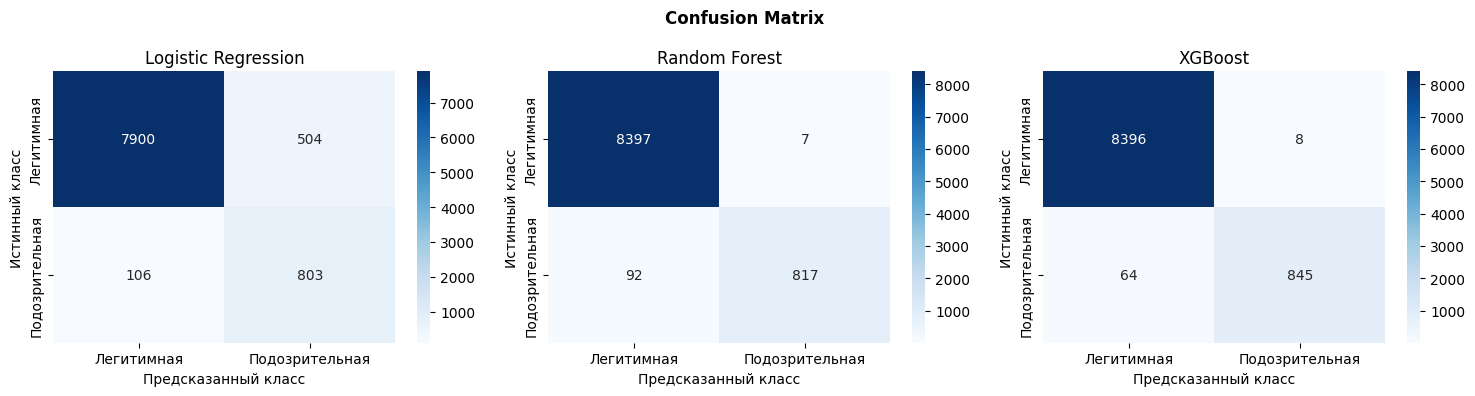

In [19]:
#Confusion Matrix — смотрим на ошибки
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix', fontweight='bold')

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Легитимная', 'Подозрительная'],
                yticklabels=['Легитимная', 'Подозрительная'])
    ax.set_title(name)
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

plt.tight_layout()
plt.show()

"XGBoost показал наилучший результат — обнаружил 845 из 909 мошеннических транзакций, пропустив лишь 64. Количество ложных тревог минимально (8), что снижает нагрузку на комплаенс-офицеров. Logistic Regression уступает по обоим показателям — 504 ложные тревоги создали бы избыточную нагрузку на регулятора."

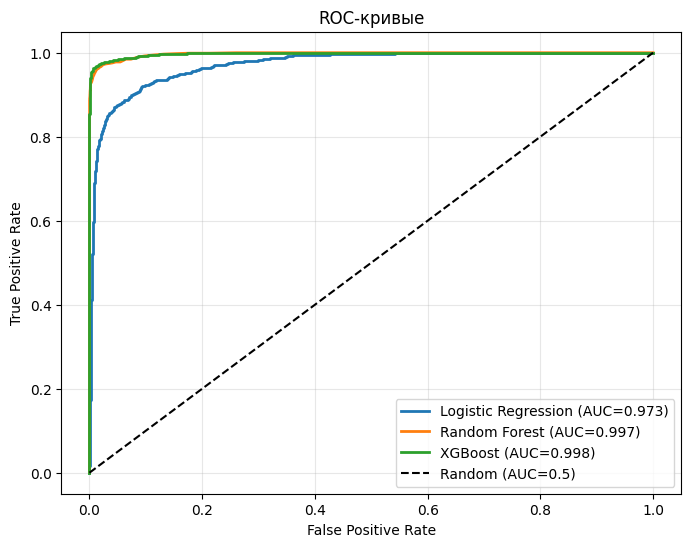

In [20]:
#ROC-кривая — визуальная проверка
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, y_proba in [('Logistic Regression', y_proba_lr),
                       ('Random Forest', y_proba_rf),
                       ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 8.3 Сравнительная таблица моделей

In [26]:
summary = pd.DataFrame({
    'Logistic Regression': {'ROC-AUC': roc_auc_score(y_test, y_proba_lr), 'F1': f1_score(y_test, y_pred_lr)},
    'Random Forest':       {'ROC-AUC': roc_auc_score(y_test, y_proba_rf), 'F1': f1_score(y_test, y_pred_rf)},
    'XGBoost':             {'ROC-AUC': roc_auc_score(y_test, y_proba_xgb),'F1': f1_score(y_test, y_pred_xgb)},
}).T
print(summary)

                      ROC-AUC        F1
Logistic Regression  0.972640  0.724729
Random Forest        0.997117  0.942874
XGBoost              0.997715  0.959137


### 8.4 Кросс-валидация
Проверяем что модели не переобучены — результаты должны быть близки к тестовым.

In [21]:
from sklearn.model_selection import cross_val_score

print('Кросс-валидация (5 фолдов):')
for name, model in [('Logistic Regression', lr),
                     ('Random Forest', rf),
                     ('XGBoost', xgb)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

Кросс-валидация (5 фолдов):
Logistic Regression: 0.9499 ± 0.0272
Random Forest: 0.9718 ± 0.0362
XGBoost: 0.9661 ± 0.0306


Кросс-валидация подтвердила корректность моделей — разница между результатами на тестовой выборке и кросс-валидацией не превышает 0.032, что свидетельствует об отсутствии переобучения. Все три модели показали устойчивые результаты

## **Оптимизация гиперпараметров XGBoost**

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Параметры для перебора
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_base = XGBClassifier(
    random_state=42, eval_metric='logloss', verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'Лучшие параметры: {search.best_params_}')
print(f'CV ROC-AUC: {search.best_score_:.4f}')

# Оценка на тесте
best_xgb = search.best_estimator_
y_pred_best  = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print(f'\nTest ROC-AUC (tuned): {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'Test F1 (tuned):      {f1_score(y_test, y_pred_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Легитимная', 'Подозрительная']))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
CV ROC-AUC: 0.9972

Test ROC-AUC (tuned): 0.9983
Test F1 (tuned):      0.9571

                precision    recall  f1-score   support

    Легитимная       0.99      1.00      1.00      8404
Подозрительная       1.00      0.92      0.96       909

      accuracy                           0.99      9313
     macro avg       0.99      0.96      0.98      9313
  weighted avg       0.99      0.99      0.99      9313



## 10. Интерпретация модели (SHAP)
Объясняем почему модель считает транзакцию подозрительной — важно для регулятора.

✅ SHAP значения вычислены


/tmp/ipykernel_8731/3492667280.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feat_cols, plot_type='bar', max_display=15, show=False)


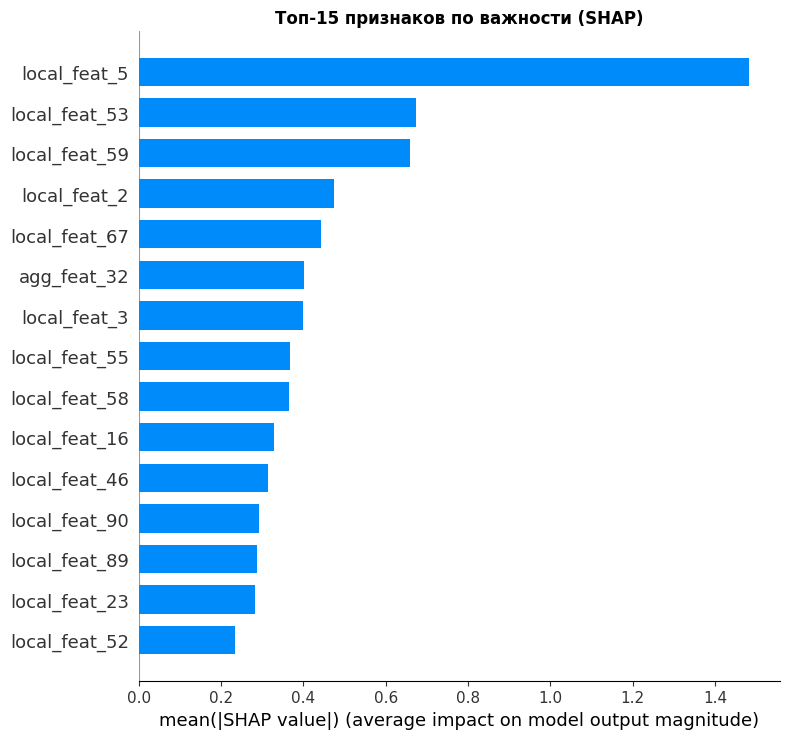

/tmp/ipykernel_8731/3492667280.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feat_cols, max_display=15, show=False)


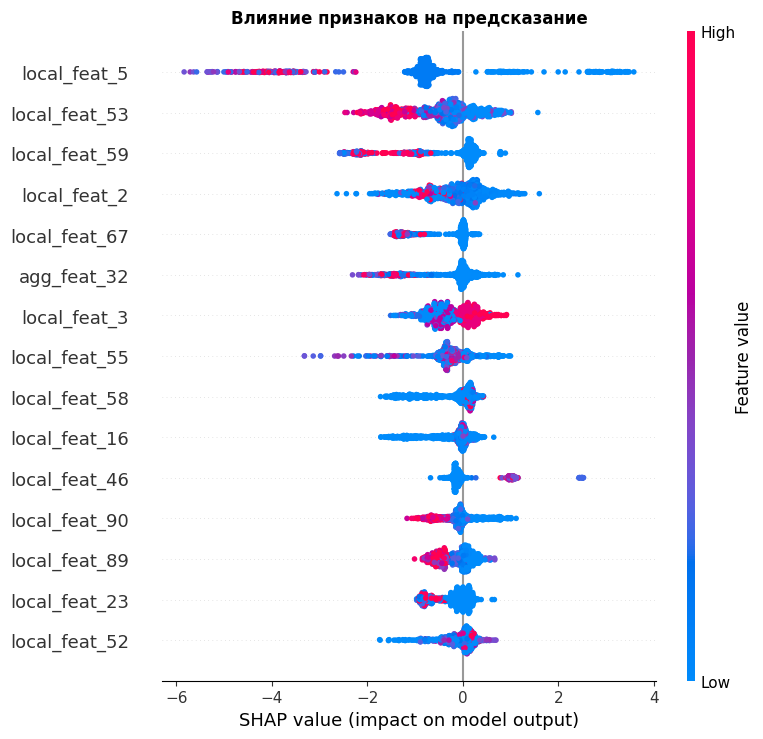

In [22]:
import shap
import numpy as np

# Берём сэмпл для скорости
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=1000)
X_shap = X_test[sample_idx]

# Вычисляем SHAP значения
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)
print('✅ SHAP значения вычислены')

# График 1 — важность признаков (bar)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feat_cols, plot_type='bar', max_display=15, show=False)
plt.title('Топ-15 признаков по важности (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

# График 2 — влияние признаков (dots)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feat_cols, max_display=15, show=False)
plt.title('Влияние признаков на предсказание', fontweight='bold')
plt.tight_layout()
plt.show()

SHAP-анализ выявил что наибольшее влияние на предсказание оказывает local_feat_5 — его низкие значения являются сильным индикатором мошеннической транзакции. 14 из 15 наиболее важных признаков относятся к локальным характеристикам транзакции, что подтверждает выводы EDA о том, что мошеннические транзакции прежде всего отличаются собственными параметрами.

## 11. Анализ стабильности данных (Data Drift)
Проверяем насколько данные изменились со временем с помощью метрики PSI.

In [23]:
from scipy import stats
import numpy as np

# ---- PSI функция ----
def compute_psi(expected, actual, buckets=10, eps=1e-6):
    bins = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    bins[0]  = -np.inf
    bins[-1] =  np.inf

    exp_counts = np.histogram(expected, bins=bins)[0]
    act_counts = np.histogram(actual,   bins=bins)[0]

    exp_pct = exp_counts / len(expected) + eps
    act_pct = act_counts / len(actual)   + eps

    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

# Временные шаги из df_labeled
timesteps = df_labeled['timestep'].values
X_all = df_labeled[feat_cols].values

# Baseline — первые 10 шагов
reference_mask = timesteps <= 10
X_ref = X_all[reference_mask]

# PSI по периодам
windows = [(11,20), (21,30), (31,40), (41,49)]
top10_idx = [feat_cols.index(f) for f in top20.head(10).index]

print('PSI: < 0.1 = стабильно | 0.1-0.25 = умеренный дрейф | > 0.25 = критический дрейф')
print()

window_psi = {}
for w_start, w_end in windows:
    w_mask = (timesteps >= w_start) & (timesteps <= w_end)
    X_window = X_all[w_mask]
    psi_vals = [compute_psi(X_ref[:, i], X_window[:, i]) for i in top10_idx]
    avg_psi = np.mean(psi_vals)
    window_psi[f'{w_start}-{w_end}'] = avg_psi
    status = '✅ Стабильно' if avg_psi < 0.1 else ('⚠️ Умеренный дрейф' if avg_psi < 0.25 else '🚨 Критический дрейф')
    print(f'Период {w_start}-{w_end}: PSI = {avg_psi:.4f} → {status}')

PSI: < 0.1 = стабильно | 0.1-0.25 = умеренный дрейф | > 0.25 = критический дрейф

Период 11-20: PSI = 0.3621 → 🚨 Критический дрейф
Период 21-30: PSI = 0.3940 → 🚨 Критический дрейф
Период 31-40: PSI = 0.9851 → 🚨 Критический дрейф
Период 41-49: PSI = 0.8644 → 🚨 Критический дрейф


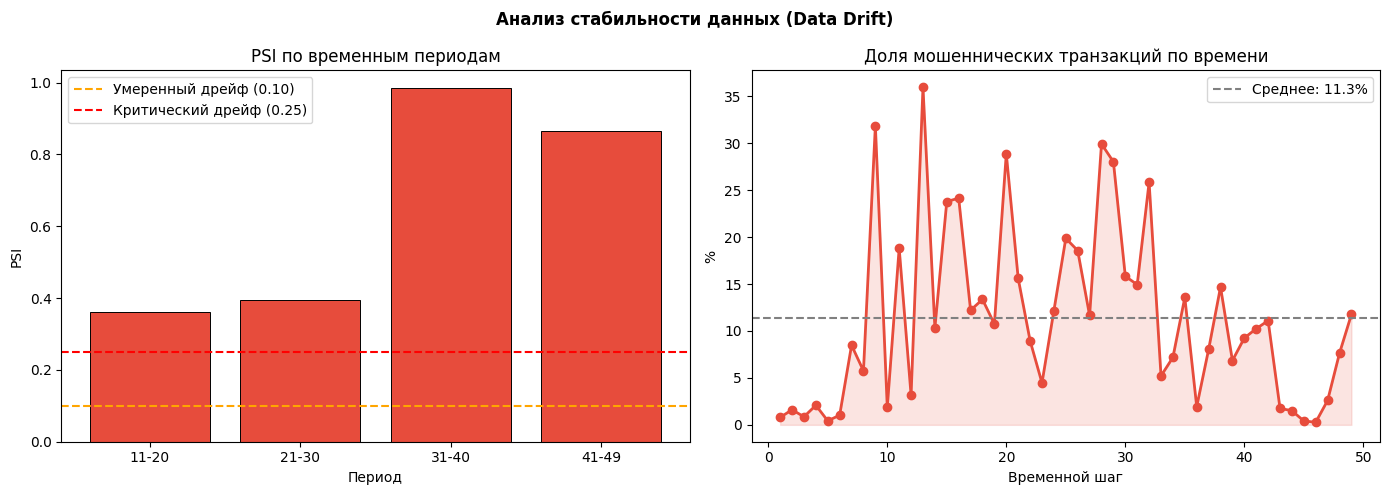

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Анализ стабильности данных (Data Drift)', fontweight='bold')

periods = list(window_psi.keys())
psi_values = list(window_psi.values())

axes[0].bar(periods, psi_values, color='#e74c3c', edgecolor='black', linewidth=0.7)
axes[0].axhline(0.10, color='orange', linestyle='--', linewidth=1.5, label='Умеренный дрейф (0.10)')
axes[0].axhline(0.25, color='red', linestyle='--', linewidth=1.5, label='Критический дрейф (0.25)')
axes[0].set_title('PSI по временным периодам')
axes[0].set_xlabel('Период')
axes[0].set_ylabel('PSI')
axes[0].legend()

illicit_rate = df_labeled.groupby('timestep')['label'].mean() * 100
axes[1].plot(illicit_rate.index, illicit_rate.values, marker='o', color='#e74c3c', linewidth=2)
axes[1].fill_between(illicit_rate.index, illicit_rate.values, alpha=0.15, color='#e74c3c')
axes[1].axhline(illicit_rate.mean(), color='gray', linestyle='--', label=f'Среднее: {illicit_rate.mean():.1f}%')
axes[1].set_title('Доля мошеннических транзакций по времени')
axes[1].set_xlabel('Временной шаг')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Сохранение модели и зависимостей
Сохраняем обученную модель и список зависимостей для воспроизводимости.

In [25]:
!pip freeze > requirements.txt
print('✅ requirements.txt создан')

✅ requirements.txt создан


In [27]:
import joblib
joblib.dump(xgb, 'aml_xgboost_model.pkl')
joblib.dump(scaler if 'scaler' in dir() else 'no_scaler', 'aml_scaler.pkl')
print('✅ Модель сохранена')

✅ Модель сохранена
